In [9]:
import pandas as pd
import matplotlib.pyplot as plt 
import openpyxl as op


In [10]:
df = pd.read_excel("dados-cti.xlsx")
print(df.head())

                Nome-Card Data-Inicio   Data-Fim  Dias-Uteis  Dias-Corridos  \
0             Alinhamento  2026-03-02 2026-03-03         1.0            1.0   
1                Kick-Off  2026-03-03 2026-03-04         1.0            1.0   
2            Configuração  2026-03-03 2026-03-04         1.0            1.0   
3            Double Check         NaT 2026-03-04         NaN            NaN   
4  Encaminhar dispositivo  2026-03-05 2026-03-09         2.0            4.0   

   Atrasado  
0     False  
1     False  
2     False  
3     False  
4      True  


In [11]:
total_dias_uteis = df["Dias-Uteis"].sum()
total_dias_corridos = df["Dias-Corridos"].sum()
print("Total de dias úteis:", total_dias_uteis)
print("Total de dias corridos:", total_dias_corridos)


Total de dias úteis: 25.0
Total de dias corridos: 33.0


Top 3 dias úteis:
Top 3 dias corridos:


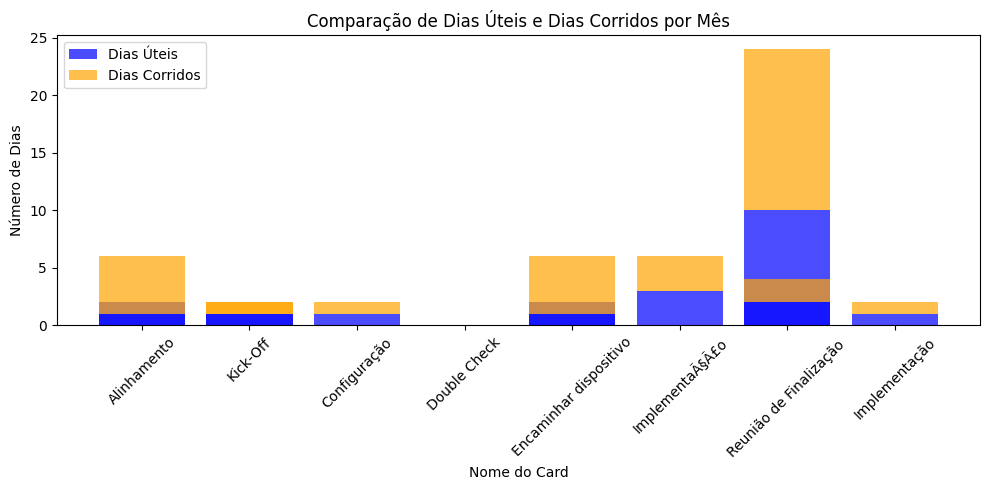

In [12]:
top3_dias_uteis = df.nlargest(3, "Dias-Uteis")
print("Top 3 dias úteis:")
top3_dias_corridos = df.nlargest(3, "Dias-Corridos")
print("Top 3 dias corridos:")
plt.figure(figsize=(10, 5))
plt.bar(df["Nome-Card"], df["Dias-Uteis"], label="Dias Úteis", color="blue", alpha=0.7)
plt.bar(df["Nome-Card"], df["Dias-Corridos"], bottom=df["Dias-Uteis"],
        label="Dias Corridos", color="orange", alpha=0.7)
plt.xlabel("Nome do Card")
plt.ylabel("Número de Dias")
plt.title("Comparação de Dias Úteis e Dias Corridos por Mês")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

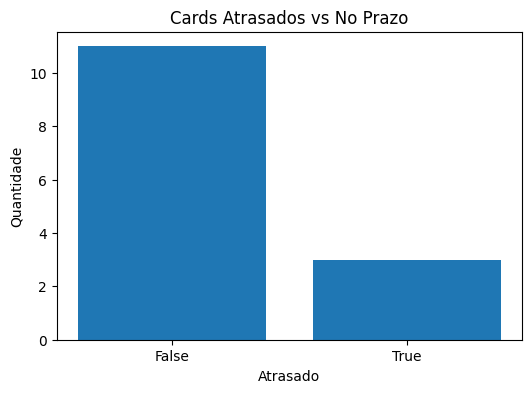

In [13]:
contagem = df['Atrasado'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(contagem.index.astype(str), contagem.values)

plt.title('Cards Atrasados vs No Prazo')
plt.xlabel('Atrasado')
plt.ylabel('Quantidade')

plt.show()

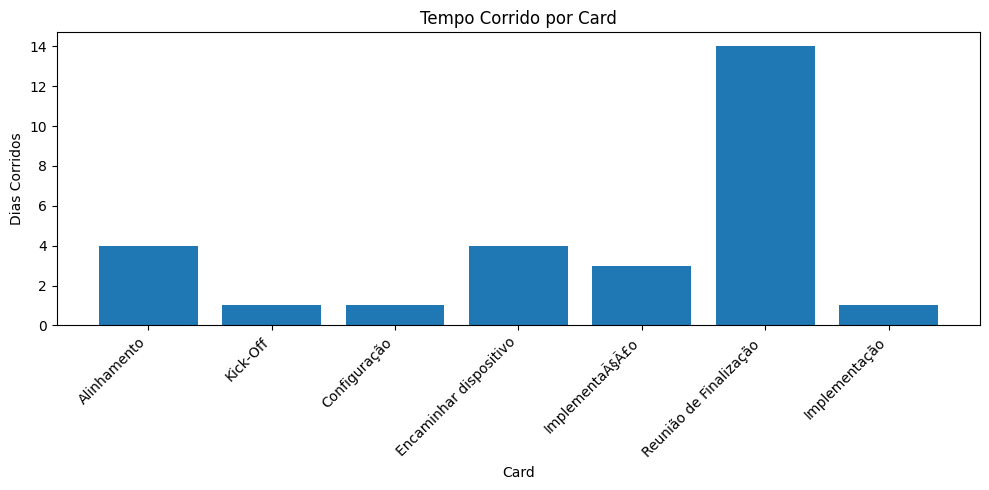

In [14]:
import matplotlib.pyplot as plt

# remover valores nulos
base = df.dropna(subset=['Dias-Corridos'])

plt.figure(figsize=(10,5))

plt.bar(base['Nome-Card'], base['Dias-Corridos'])

plt.xticks(rotation=45, ha='right')

plt.title('Tempo Corrido por Card')
plt.xlabel('Card')
plt.ylabel('Dias Corridos')

plt.tight_layout()
plt.show()

In [15]:
plt.figure(figsize=(10,5))

plt.bar(['Dias-Uteis'], width=0.4, label='Dias Uteis')
plt.bar([i + 0.4 for i in x], base['Dias-Corridos'], width=0.4, label='Dias Corridos')

plt.xticks([i + 0.2 for i in x], base['Nome-Card'], rotation=45, ha='right')

plt.title('Dias Úteis vs Dias Corridos')
plt.ylabel('Quantidade de Dias')
plt.legend()

plt.tight_layout()
plt.show()

TypeError: bar() missing 1 required positional argument: 'height'

<Figure size 1000x500 with 0 Axes>

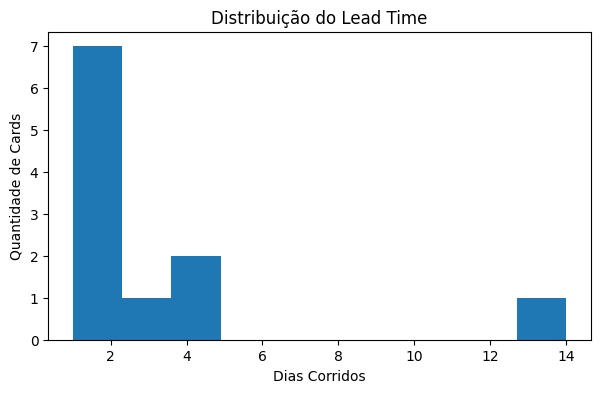

In [ ]:
base = df.dropna(subset=['Dias-Corridos'])

plt.figure(figsize=(7,4))

plt.hist(base['Dias-Corridos'])

plt.title('Distribuição do Lead Time')
plt.xlabel('Dias Corridos')
plt.ylabel('Quantidade de Cards')

plt.show()

In [ ]:
# IMPORTANTE: Esse código assume que você já rodou suas células anteriores 
# e a variável 'df' já existe na memória com os dados que você mostrou!

# 1. Criar uma cópia para não estragar o seu df original
df_graficos = df.copy()

# 2. Corrigir os nomes dos cards para o gráfico ficar bonito
df_graficos['Nome-Card'] = df_graficos['Nome-Card'].astype(str).str.strip()
df_graficos['Nome-Card'] = df_graficos['Nome-Card'].replace({
    'ConfiguraÃ§Ã£o': 'Configuração',
    'ImplementaÃ§Ã£o': 'Implementação',
    'ReuniÃ£o de finalizaÃ§Ã£o': 'Reunião de Finalização'
})

# 3. Converter com segurança os Timedeltas existentes para HORAS (número float)
# Usamos o .dt.total_seconds() porque ele calcula os dias + horas e converte tudo em segundos
df_graficos['H-Total'] = pd.to_timedelta(df_graficos['Tempo-Total'], errors='coerce').dt.total_seconds() / 3600
df_graficos['H-Trabalho'] = pd.to_timedelta(df_graficos['Tempo-Trabalho'], errors='coerce').dt.total_seconds() / 3600

# Filtrar linhas sem dados de tempo (como o Double Check)
df_validos = df_graficos.dropna(subset=['H-Total', 'H-Trabalho']).copy()

# ---------------------------------------------------------------------------
# GERAÇÃO DOS TRÊS GRÁFICOS SOLICITADOS (LADO A LADO: TRABALHO VS TOTAL)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
fig.suptitle("Análise de Tempo-Trabalho vs Tempo-Total", fontsize=16, fontweight='bold')

width = 0.35

# --- GRÁFICO 1: 5 MAIORES TEMPOS ---
top5_maiores = df_validos.nlargest(5, 'H-Total')
x1 = range(len(top5_maiores))

axes[0].bar([i - width/2 for i in x1], top5_maiores['H-Trabalho'], width, label='Tempo-Trabalho', color='#3498db')
axes[0].bar([i + width/2 for i in x1], top5_maiores['H-Total'], width, label='Tempo-Total', color='#e74c3c')
axes[0].set_title("Top 5 MAIORES Tempos por Card", fontsize=12, fontweight='bold')
axes[0].set_xticks(x1)
axes[0].set_xticklabels(top5_maiores['Nome-Card'], rotation=15, ha='right')
axes[0].set_ylabel("Horas Ocorridas")
axes[0].legend()

for i, (trab, tot) in enumerate(zip(top5_maiores['H-Trabalho'], top5_maiores['H-Total'])):
    axes[0].text(i - width/2, trab + (top5_maiores['H-Total'].max()*0.01), f"{trab:.1f}h", ha='center', va='bottom', fontsize=9)
    axes[0].text(i + width/2, tot + (top5_maiores['H-Total'].max()*0.01), f"{tot:.1f}h", ha='center', va='bottom', fontsize=9)


# --- GRÁFICO 2: 5 MENORES TEMPOS ---
top5_menores = df_validos.nsmallest(5, 'H-Total')
x2 = range(len(top5_menores))

axes[1].bar([i - width/2 for i in x2], top5_menores['H-Trabalho'], width, label='Tempo-Trabalho', color='#5da5da')
axes[1].bar([i + width/2 for i in x2], top5_menores['H-Total'], width, label='Tempo-Total', color='#faa43a')
axes[1].set_title("Top 5 MENORES Tempos por Card", fontsize=12, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(top5_menores['Nome-Card'], rotation=15, ha='right')
axes[1].set_ylabel("Horas Ocorridas")
axes[1].legend()

for i, (trab, tot) in enumerate(zip(top5_menores['H-Trabalho'], top5_menores['H-Total'])):
    axes[1].text(i - width/2, trab + (top5_menores['H-Total'].max()*0.01), f"{trab:.1f}h", ha='center', va='bottom', fontsize=9)
    axes[1].text(i + width/2, tot + (top5_menores['H-Total'].max()*0.01), f"{tot:.1f}h", ha='center', va='bottom', fontsize=9)


# --- GRÁFICO 3: ACUMULADO (SOMA TOTAL GASTA DE CADA UM) ---
df_acumulado = df_validos.groupby('Nome-Card')[['H-Trabalho', 'H-Total']].sum().sort_values(by='H-Total', ascending=False)
x3 = range(len(df_acumulado))

axes[2].bar([i - width/2 for i in x3], df_acumulado['H-Trabalho'], width, label='Total Acumulado Trabalho', color='#2ecc71')
axes[2].bar([i + width/2 for i in x3], df_acumulado['H-Total'], width, label='Total Acumulado Geral', color='#9b59b6')
axes[2].set_title("Soma do Tempo Total Gasto Acumulado por Tipo de Card", fontsize=12, fontweight='bold')
axes[2].set_xticks(x3)
axes[2].set_xticklabels(df_acumulado.index, rotation=20, ha='right')
axes[2].set_ylabel("Horas Acumuladas")
axes[2].legend()

for i, (trab, tot) in enumerate(zip(df_acumulado['H-Trabalho'], df_acumulado['H-Total'])):
    axes[2].text(i - width/2, trab + (df_acumulado['H-Total'].max()*0.01), f"{trab:.0f}h", ha='center', va='bottom', fontsize=9)
    axes[2].text(i + width/2, tot + (df_acumulado['H-Total'].max()*0.01), f"{tot:.0f}h", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()


📋 RESUMO EXECUTIVO - ANÁLISE DO QUADRO CTI


NameError: name 'df_completo' is not defined

📊 DADOS CARREGADOS E TRATADOS
Total de linhas na base original: 14
Atividades concluídas: 14
Atividades sem data de fim: 0
Colunas disponíveis: ['Nome_Card', 'Data_Inicio', 'Data_Fim', 'Dias_Uteis', 'Dias_Corridos', 'Atrasado', 'Lead_Time', 'Eficiencia']

📈 INSIGHT 1: CARDS COM MAIOR LEAD TIME
              Nome_Card  Lead_Time Data_Inicio   Data_Fim
Reunião de Finalização        14.0  2026-03-12 2026-03-26
 Encaminhar dispositivo        4.0  2026-03-05 2026-03-09
            Alinhamento        4.0  2026-02-27 2026-03-03
        ImplementaÃ§Ã£o        3.0  2026-03-09 2026-03-12
Reunião de Finalização         2.0  2026-03-11 2026-03-13
            Alinhamento        1.0  2026-03-02 2026-03-03
               Kick-Off        1.0  2026-03-03 2026-03-04
           Configuração        1.0  2026-03-03 2026-03-04
               Kick-Off        1.0  2026-03-03 2026-03-04
 Encaminhar dispositivo        1.0  2026-03-05 2026-03-06


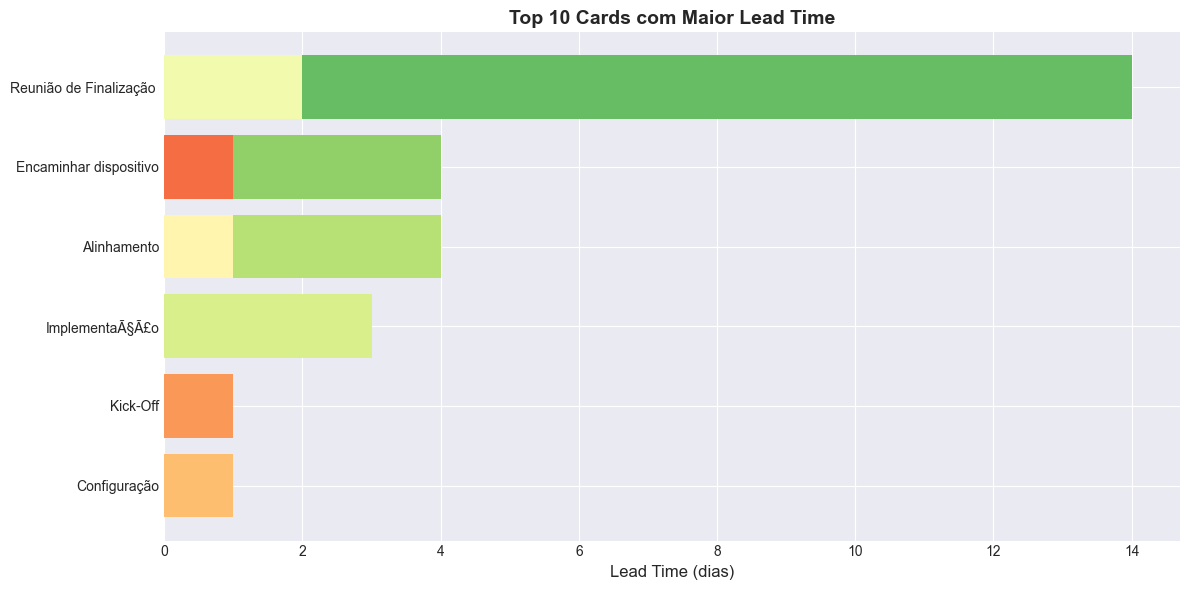


📊 INSIGHT 2: ANÁLISE DE ATRASOS
✅ Não atrasados: 11 cards (78.6%)
⚠️ Atrasados: 3 cards (21.4%)


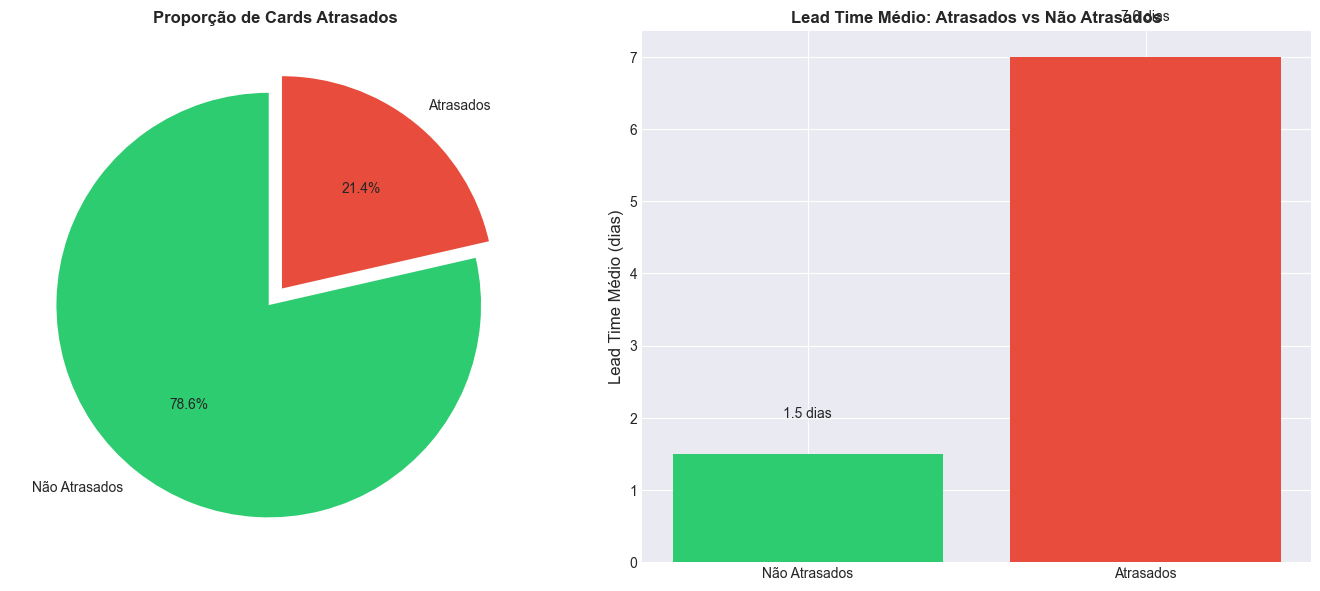


⏱️ INSIGHT 3: EFICIÊNCIA
Média de dias corridos: 3.0 dias
Média de dias úteis: 2.3 dias
Eficiência média: 88.3%

📅 Cards com mais dias de fim de semana no período:
              Nome_Card  Dias_Corridos  Dias_Uteis  Diferenca
Reunião de Finalização            14.0        10.0        4.0
 Encaminhar dispositivo            4.0         2.0        2.0
            Alinhamento            4.0         2.0        2.0
            Alinhamento            1.0         1.0        0.0
               Kick-Off            1.0         1.0        0.0


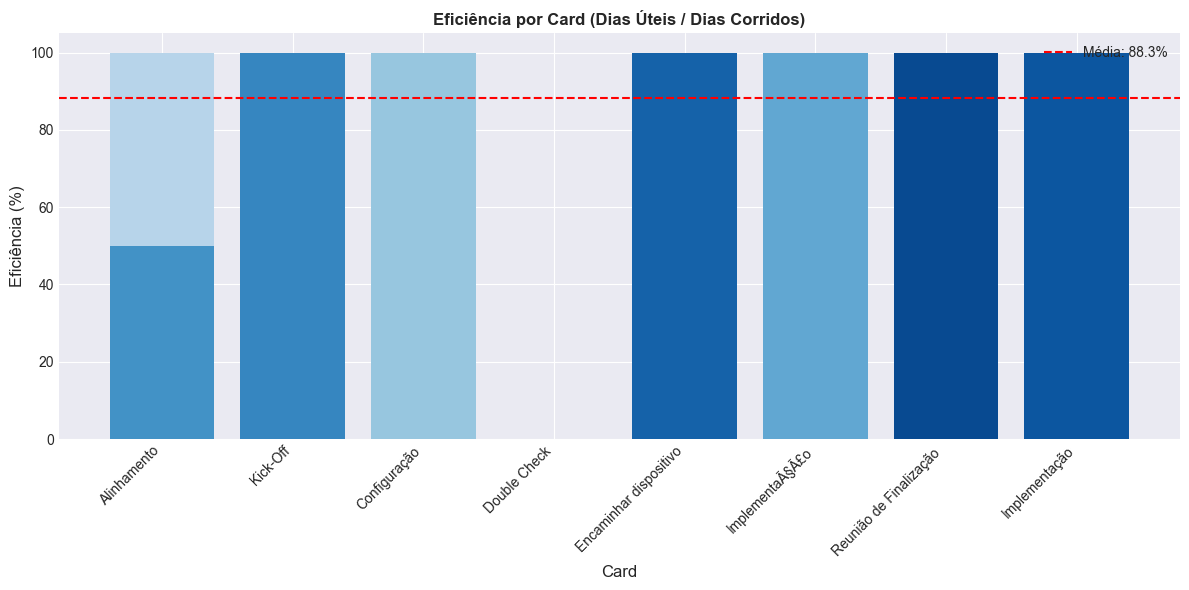


🔄 INSIGHT 4: CARDS REPETIDOS
📌 Alinhamento: 2 vezes
📌 Kick-Off: 2 vezes
📌 Configuração: 2 vezes
📌 Double Check: 2 vezes
📌 Encaminhar dispositivo: 2 vezes
📌 Reunião de Finalização : 2 vezes

📈 INSIGHT 5: TENDÊNCIA DE LEAD TIME
Lead time médio geral: 3.0 dias
Lead time mínimo: 1.0 dias
Lead time máximo: 14.0 dias


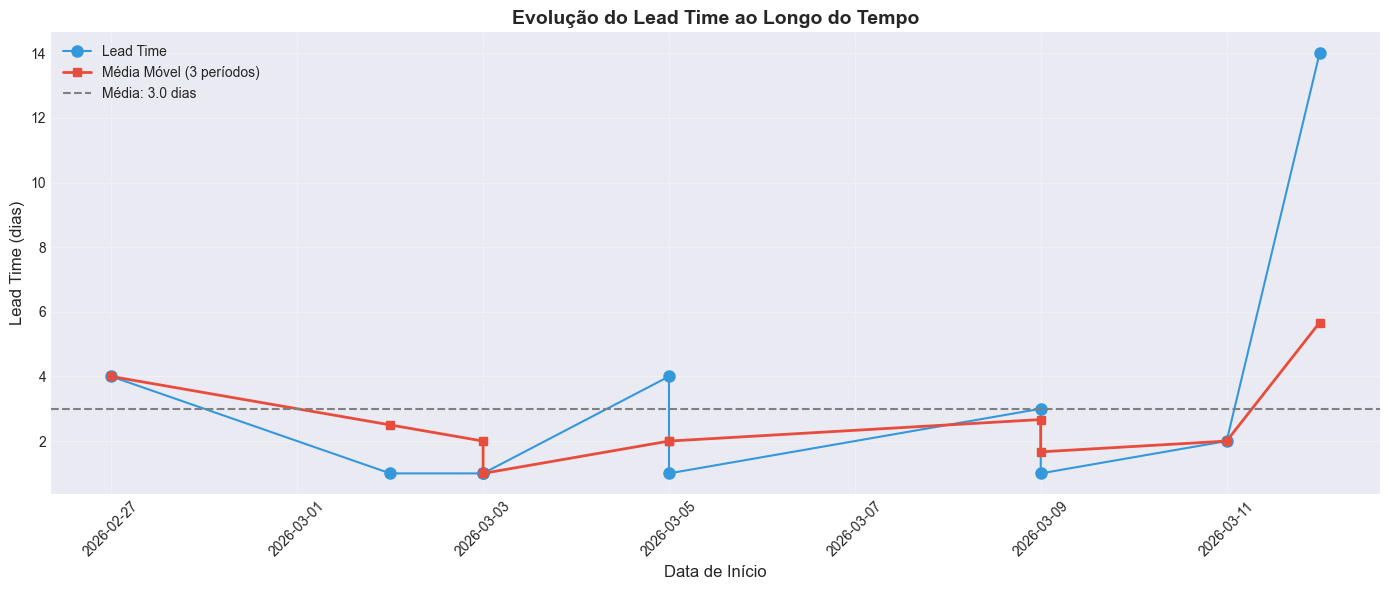


📋 RESUMO EXECUTIVO - ANÁLISE DO QUADRO CTI

┌─────────────────────────────────────────────────────────────────┐
│                          MÉTRICAS GERAIS                         │
├─────────────────────────────────────────────────────────────────┤
│ Total de atividades analisadas:      14                         │
│ Taxa de atraso:                      21.4%                         │
│ Lead time médio (dias):              3.0                          │
│ Lead time mínimo (dias):             1                          │
│ Lead time máximo (dias):             14                          │
├─────────────────────────────────────────────────────────────────┤
│                        PRINCIPAIS GARGALOS                       │
├─────────────────────────────────────────────────────────────────┤
│ Card com maior lead time:            Reunião de Finalização                           │
│ Card com mais fins de semana:        Reunião de Finalização                           │
│ Cards que mais se

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

# =========================================
# 1. CARREGAR OS DADOS (USANDO SUA VARIÁVEL df)
# =========================================
# Assumindo que você já tem o df carregado, vamos trabalhar com ele

# Se precisar recarregar, descomente a linha abaixo:
# df = pd.read_excel('dados-cti.xlsx', sheet_name='Planilha1')

# Renomear colunas para facilitar
df.columns = ['Nome_Card', 'Data_Inicio', 'Data_Fim', 'Dias_Uteis', 'Dias_Corridos', 'Atrasado']

# Converter datas
df['Data_Inicio'] = pd.to_datetime(df['Data_Inicio'], errors='coerce')
df['Data_Fim'] = pd.to_datetime(df['Data_Fim'], errors='coerce')

# Converter Atrasado para booleano
df['Atrasado'] = df['Atrasado'].astype(str).str.lower() == 'true'

# Criar DataFrame apenas com atividades concluídas (que têm Data_Fim)
df_completo = df.dropna(subset=['Data_Fim']).copy()

# Calcular lead time em dias corridos
df_completo['Lead_Time'] = (df_completo['Data_Fim'] - df_completo['Data_Inicio']).dt.days

# Calcular eficiência (dias úteis / dias corridos)
df_completo['Eficiencia'] = (df_completo['Dias_Uteis'] / df_completo['Dias_Corridos'] * 100).round(1)

print("=" * 60)
print("📊 DADOS CARREGADOS E TRATADOS")
print("=" * 60)
print(f"Total de linhas na base original: {len(df)}")
print(f"Atividades concluídas: {len(df_completo)}")
print(f"Atividades sem data de fim: {len(df) - len(df_completo)}")
print(f"Colunas disponíveis: {df_completo.columns.tolist()}")

# =========================================
# INSIGHT 1: TOP CARDS COM MAIOR LEAD TIME
# =========================================
print("\n" + "=" * 60)
print("📈 INSIGHT 1: CARDS COM MAIOR LEAD TIME")
print("=" * 60)

top_lead_time = df_completo.nlargest(10, 'Lead_Time')[['Nome_Card', 'Lead_Time', 'Data_Inicio', 'Data_Fim']]
print(top_lead_time.to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))
cores = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_lead_time)))
ax.barh(top_lead_time['Nome_Card'], top_lead_time['Lead_Time'], color=cores)
ax.set_xlabel('Lead Time (dias)', fontsize=12)
ax.set_title('Top 10 Cards com Maior Lead Time', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('insight_1_lead_time.png', dpi=150, bbox_inches='tight')
plt.show()

# =========================================
# INSIGHT 2: CARDS ATRASADOS
# =========================================
print("\n" + "=" * 60)
print("📊 INSIGHT 2: ANÁLISE DE ATRASOS")
print("=" * 60)

atrasados_count = df_completo['Atrasado'].value_counts()
total_concluidos = len(df_completo)
qtd_atrasados = atrasados_count.get(True, 0)
qtd_nao_atrasados = atrasados_count.get(False, 0)

print(f"✅ Não atrasados: {qtd_nao_atrasados} cards ({qtd_nao_atrasados/total_concluidos*100:.1f}%)")
print(f"⚠️ Atrasados: {qtd_atrasados} cards ({qtd_atrasados/total_concluidos*100:.1f}%)")

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cores_pizza = ['#2ecc71', '#e74c3c']
labels = ['Não Atrasados', 'Atrasados']
sizes = [qtd_nao_atrasados, qtd_atrasados]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=cores_pizza, startangle=90, explode=(0.05, 0.05))
axes[0].set_title('Proporção de Cards Atrasados', fontsize=12, fontweight='bold')

lead_time_atrasados = df_completo.groupby('Atrasado')['Lead_Time'].mean()
axes[1].bar(['Não Atrasados', 'Atrasados'], lead_time_atrasados.values, color=cores_pizza)
axes[1].set_ylabel('Lead Time Médio (dias)', fontsize=12)
axes[1].set_title('Lead Time Médio: Atrasados vs Não Atrasados', fontsize=12, fontweight='bold')
for i, v in enumerate(lead_time_atrasados.values):
    axes[1].text(i, v + 0.5, f'{v:.1f} dias', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('insight_2_atrasados.png', dpi=150, bbox_inches='tight')
plt.show()

# =========================================
# INSIGHT 3: EFICIÊNCIA (DIAS ÚTEIS VS CORRIDOS)
# =========================================
print("\n" + "=" * 60)
print("⏱️ INSIGHT 3: EFICIÊNCIA")
print("=" * 60)

print(f"Média de dias corridos: {df_completo['Dias_Corridos'].mean():.1f} dias")
print(f"Média de dias úteis: {df_completo['Dias_Uteis'].mean():.1f} dias")
print(f"Eficiência média: {df_completo['Eficiencia'].mean():.1f}%")

df_completo['Diferenca'] = df_completo['Dias_Corridos'] - df_completo['Dias_Uteis']
top_fds = df_completo.nlargest(5, 'Diferenca')[['Nome_Card', 'Dias_Corridos', 'Dias_Uteis', 'Diferenca']]
print("\n📅 Cards com mais dias de fim de semana no período:")
print(top_fds.to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))
cores = plt.cm.Blues(np.linspace(0.3, 0.9, len(df_completo)))
ax.bar(df_completo['Nome_Card'], df_completo['Eficiencia'], color=cores)
ax.axhline(y=df_completo['Eficiencia'].mean(), color='red', linestyle='--', label=f"Média: {df_completo['Eficiencia'].mean():.1f}%")
ax.set_ylabel('Eficiência (%)', fontsize=12)
ax.set_xlabel('Card', fontsize=12)
ax.set_title('Eficiência por Card (Dias Úteis / Dias Corridos)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('insight_3_eficiencia.png', dpi=150, bbox_inches='tight')
plt.show()

# =========================================
# INSIGHT 4: CARDS DUPLICADOS
# =========================================
print("\n" + "=" * 60)
print("🔄 INSIGHT 4: CARDS REPETIDOS")
print("=" * 60)

card_counts = df_completo['Nome_Card'].value_counts()
cards_repetidos = card_counts[card_counts > 1]

if len(cards_repetidos) > 0:
    for card, count in cards_repetidos.items():
        print(f"📌 {card}: {count} vezes")
else:
    print("Nenhum card repetido encontrado")

# =========================================
# INSIGHT 5: TENDÊNCIA AO LONGO DO TEMPO
# =========================================
print("\n" + "=" * 60)
print("📈 INSIGHT 5: TENDÊNCIA DE LEAD TIME")
print("=" * 60)

df_ordenado = df_completo.sort_values('Data_Inicio').copy()
df_ordenado['Lead_Time_Media_Movel'] = df_ordenado['Lead_Time'].rolling(window=3, min_periods=1).mean()

print(f"Lead time médio geral: {df_ordenado['Lead_Time'].mean():.1f} dias")
print(f"Lead time mínimo: {df_ordenado['Lead_Time'].min()} dias")
print(f"Lead time máximo: {df_ordenado['Lead_Time'].max()} dias")

# Gráfico
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_ordenado['Data_Inicio'], df_ordenado['Lead_Time'], 'o-', label='Lead Time', color='#3498db', markersize=8)
ax.plot(df_ordenado['Data_Inicio'], df_ordenado['Lead_Time_Media_Movel'], 's-', label='Média Móvel (3 períodos)', color='#e74c3c', linewidth=2)
ax.axhline(y=df_ordenado['Lead_Time'].mean(), color='gray', linestyle='--', label=f"Média: {df_ordenado['Lead_Time'].mean():.1f} dias")
ax.set_xlabel('Data de Início', fontsize=12)
ax.set_ylabel('Lead Time (dias)', fontsize=12)
ax.set_title('Evolução do Lead Time ao Longo do Tempo', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('insight_5_tendencia.png', dpi=150, bbox_inches='tight')
plt.show()

# =========================================
# RESUMO EXECUTIVO
# =========================================
print("\n" + "=" * 70)
print("📋 RESUMO EXECUTIVO - ANÁLISE DO QUADRO CTI")
print("=" * 70)

# Calcular valores para o resumo
card_maior_lead = top_lead_time.iloc[0]['Nome_Card'] if len(top_lead_time) > 0 else "N/A"
card_mais_fds = top_fds.iloc[0]['Nome_Card'] if len(top_fds) > 0 else "N/A"
card_mais_repetido = cards_repetidos.index[0] if len(cards_repetidos) > 0 else "Nenhum"

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│                          MÉTRICAS GERAIS                         │
├─────────────────────────────────────────────────────────────────┤
│ Total de atividades analisadas:     {len(df_completo):3d}                         │
│ Taxa de atraso:                      {qtd_atrasados/len(df_completo)*100:.1f}%                         │
│ Lead time médio (dias):              {df_completo['Lead_Time'].mean():.1f}                          │
│ Lead time mínimo (dias):             {df_completo['Lead_Time'].min():.0f}                          │
│ Lead time máximo (dias):             {df_completo['Lead_Time'].max():.0f}                          │
├─────────────────────────────────────────────────────────────────┤
│                        PRINCIPAIS GARGALOS                       │
├─────────────────────────────────────────────────────────────────┤
│ Card com maior lead time:            {card_maior_lead}                          │
│ Card com mais fins de semana:        {card_mais_fds}                          │
│ Cards que mais se repetem:           {card_mais_repetido}                          │
└─────────────────────────────────────────────────────────────────┘
""")

# =========================================
# EXPORTAR PARA EXCEL
# =========================================
try:
    with pd.ExcelWriter('insights_cti.xlsx', engine='openpyxl') as writer:
        df_completo.to_excel(writer, sheet_name='Dados_Completos', index=False)
        top_lead_time.to_excel(writer, sheet_name='Top_Lead_Time', index=False)
        pd.DataFrame({
            'Métrica': ['Total Cards', 'Cards Atrasados', 'Taxa Atraso', 'Lead Time Médio', 'Eficiência Média'],
            'Valor': [len(df_completo), qtd_atrasados, f"{qtd_atrasados/len(df_completo)*100:.1f}%", 
                      f"{df_completo['Lead_Time'].mean():.1f} dias", f"{df_completo['Eficiencia'].mean():.1f}%"]
        }).to_excel(writer, sheet_name='Resumo', index=False)
    print("\n✅ Arquivo 'insights_cti.xlsx' gerado com todos os dados!")
except Exception as e:
    print(f"\n⚠️ Erro ao gerar Excel: {e}")

print("\n✅ Análise concluída! Gráficos salvos como PNG.")

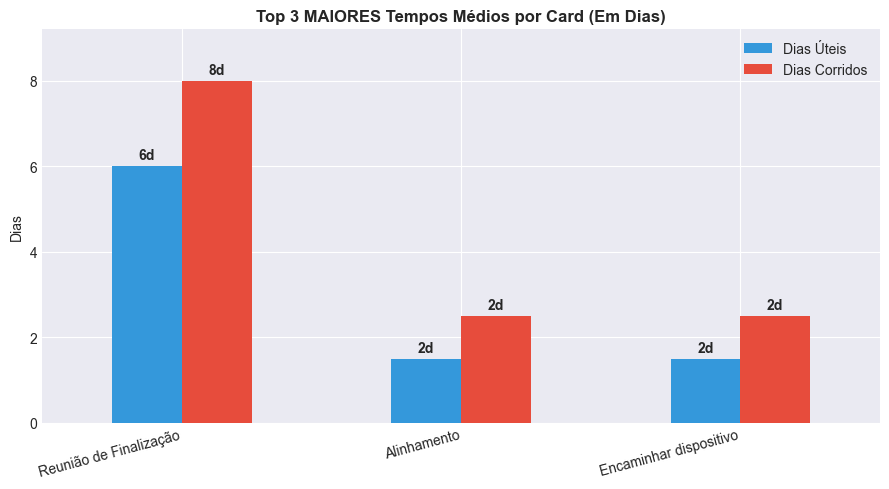

In [ ]:
#gemini

# 1. Agrupar por Card (tirando a média) para limpar as duplicidades e tratar nulos
df_agrupado = df.dropna(subset=['Dias_Uteis', 'Dias_Corridos']).groupby('Nome_Card')[['Dias_Uteis', 'Dias_Corridos']].mean().reset_index()

# 2. Filtrar os 3 maiores com base em Dias_Corridos (Lead Time)
top3_maiores = df_agrupado.nlargest(3, 'Dias_Corridos')

# 3. Plotar lado a lado de forma enxuta
ax = top3_maiores.set_index('Nome_Card')[['Dias_Uteis', 'Dias_Corridos']].plot(
    kind='bar', color=['#3498db', '#e74c3c'], figsize=(9, 5)
)

# 4. Adicionar os rótulos de dias inteiros nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.0fd', padding=3, fontweight='bold')

plt.title("Top 3 MAIORES Tempos Médios por Card (Em Dias)", fontweight="bold")
plt.ylabel("Dias")
plt.xlabel("")
plt.xticks(rotation=15, ha='right')
plt.legend(["Dias Úteis", "Dias Corridos"])
plt.ylim(0, top3_maiores['Dias_Corridos'].max() * 1.15)
plt.tight_layout()
plt.show()

In [16]:
import matplotlib.pyplot as plt

# 1. Segurança total: padroniza as colunas (corrige hífens/underlines e espaços)
df_validos.columns = df_validos.columns.str.replace('-', '_').str.strip()

# 2. Agrupar tirando a média para consolidar os cards repetidos e evitar erros
df_agrupado = df_validos.dropna(subset=['Dias_Uteis', 'Dias_Corridos']).groupby('Nome_Card')[['Dias_Uteis', 'Dias_Corridos']].mean().reset_index()

# Corrigir acentuação se necessário
df_agrupado['Nome_Card'] = df_agrupado['Nome_Card'].replace({'ImplementaÃ§Ã£o': 'Implementação'})

# 3. Filtrar os 3 maiores com base em Dias Corridos
top3_maiores = df_agrupado.nlargest(3, 'Dias_Corridos')

# 4. Plotar de forma enxuta
ax = top3_maiores.set_index('Nome_Card')[['Dias_Uteis', 'Dias_Corridos']].plot(
    kind='bar', color=["#0d00ff", "#00d0ff"], figsize=(9, 5)
)

# Adicionar os rótulos de dias inteiros nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.0fd', padding=3, fontweight='bold')

plt.title("Top 3 MAIORES Tempos Médios por Card (Em Dias)", fontweight="bold")
plt.ylabel("Dias")
plt.xlabel("")
plt.xticks(rotation=15, ha='right')
plt.legend(["Dias Úteis", "Dias Corridos"])
plt.ylim(0, top3_maiores['Dias_Corridos'].max() * 1.15)
plt.tight_layout()
plt.show()

NameError: name 'df_validos' is not defined

In [ ]:
import matplotlib.pyplot as plt

# 1. Segurança total: padroniza as colunas
df_validos.columns = df_validos.columns.str.replace('-', '_').str.strip()

# 2. Filtrar apenas os cards atrasados (tratando maiúsculas/minúsculas)
df_atrasados = df_validos[df_validos["Atrasado"].astype(str).str.upper() == "TRUE"].copy()
df_atrasados['Nome_Card'] = df_atrasados['Nome_Card'].replace({'ImplementaÃ§Ã£o': 'Implementação'})

# 3. Plotar o comparativo de dias apenas deles
ax = df_atrasados.set_index("Nome_Card")[["Dias_Uteis", "Dias_Corridos"]].plot(
    kind="bar", color=["#1100ff", "#00bfff"], figsize=(9, 5)
)

# Adicionar o rótulo de dias inteiros
for container in ax.containers:
    ax.bar_label(container, fmt="%.0fd", padding=3, fontweight="bold")

plt.title("Análise de Dias dos Cards ATRASADOS", fontweight="bold")
plt.ylabel("Dias")
plt.xlabel("")
plt.xticks(rotation=15, ha="right")
plt.legend(["Dias Úteis", "Dias Corridos"])
plt.ylim(0, df_atrasados["Dias_Corridos"].max() * 1.15)
plt.tight_layout()
plt.show()

NameError: name 'df_validos' is not defined